<a href="https://colab.research.google.com/github/Marrium-here/skills-introduction-to-github/blob/main/shielded_rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SHIELDED REINFORCEMENT LEARNING

SHIELDED REINFORCEMENT LEARNING

This will run two experiments:
1. Grid World (9x9) - 100 episodes each
2. Water Tank - 100 episodes each

Each experiment runs with and without the shield.

🚀 Starting Grid World Experiment...

────────────────────────────────────────
Training WITH Shield:
────────────────────────────────────────

TRAINING GRID WORLD
Episode 0: Reward = -79.0, Corrections = 0
Episode 24: Reward = -79.0, Corrections = 0
Episode 49: Reward = -79.0, Corrections = 0
Episode 74: Reward = -79.0, Corrections = 0
Episode 99: Reward = -100.0, Corrections = 0

Success rate: 0/100 = 0.0%
Total shield corrections: 0

────────────────────────────────────────
Training WITHOUT Shield:
────────────────────────────────────────

TRAINING GRID WORLD
Episode 0: Reward = -13.0, Corrections = 0
Episode 24: Reward = -38.0, Corrections = 0
Episode 49: Reward = -58.0, Corrections = 0
Episode 74: Reward = -30.0, Corrections = 0
Episode 99: Reward = -79.0, Correct

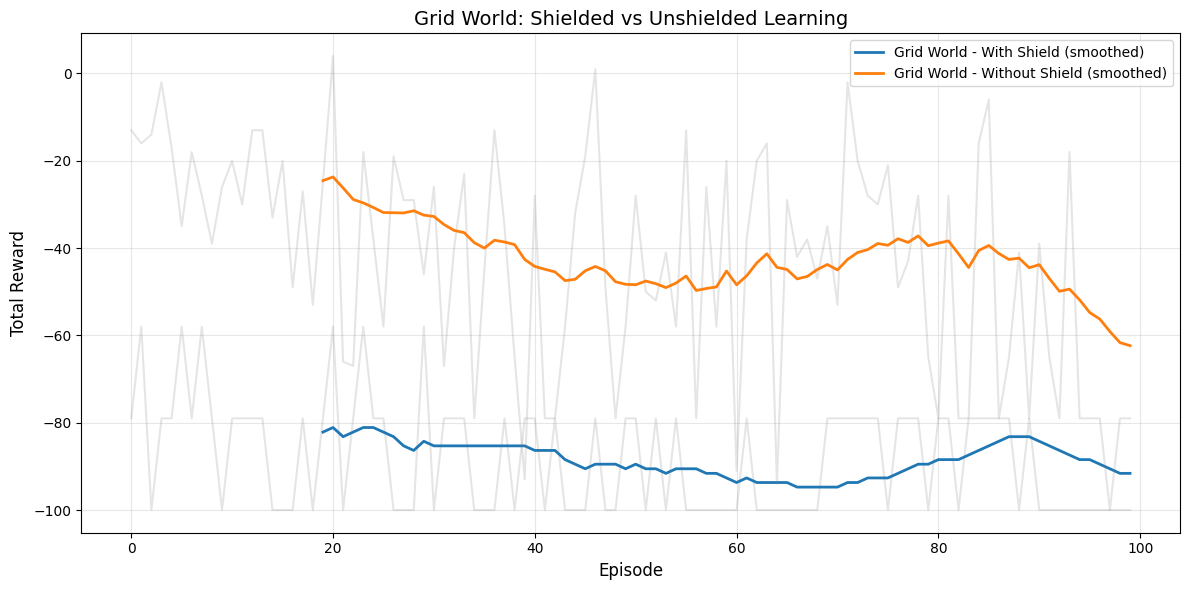

✅ Graph saved as 'water_tank_results.png'


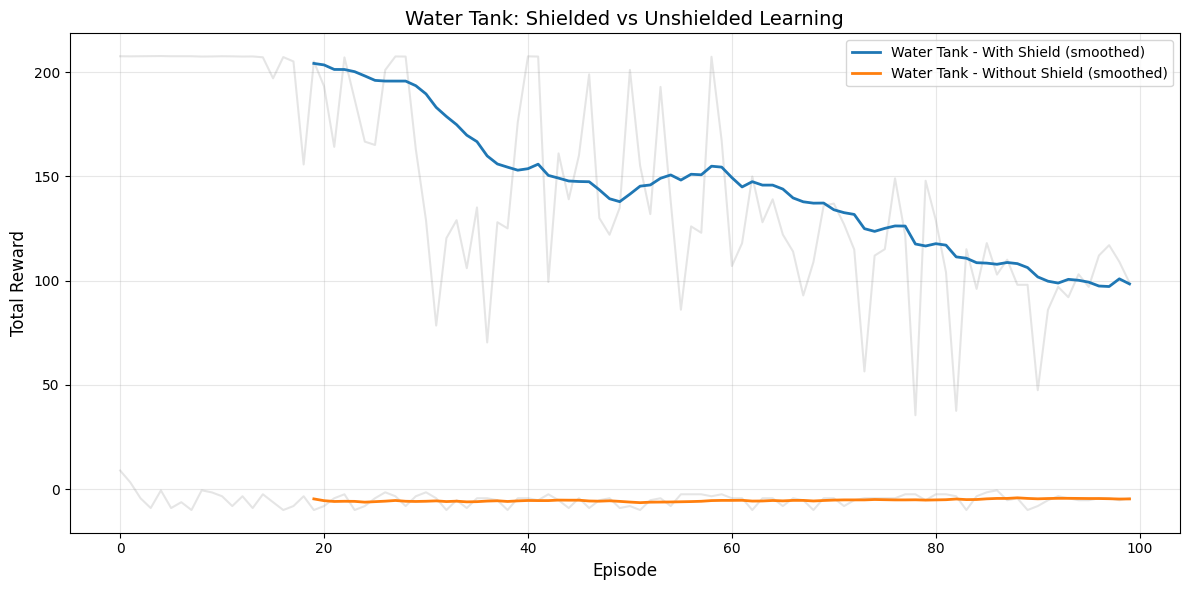


📊 FINAL SUMMARY

────────────────────────────────────────
GRID WORLD RESULTS
────────────────────────────────────────
  With Shield - Success: 0/100, Corrections: 0
  Without Shield - Success: 0/100, Corrections: 0
  Avg With Shield (last 20): -91.60
  Avg Without Shield (last 20): -62.35

────────────────────────────────────────
WATER TANK RESULTS
────────────────────────────────────────
  With Shield - Success: 100/100, Corrections: 97
  Without Shield - Success: 2/100, Corrections: 0
  Avg With Shield (last 20): 98.41
  Avg Without Shield (last 20): -4.68

🎉 ALL DONE!
📊 Two graphs will appear above.
💡 The shield blocks unsafe actions during learning.


In [4]:
# ============================================
# SHIELDED REINFORCEMENT LEARNING
# ============================================

import random
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("SHIELDED REINFORCEMENT LEARNING")
print("="*60)

# ============================================
# SHIELD CLASS
# ============================================

class Shield:
    def __init__(self, env_type='grid'):
        self.env_type = env_type
        self.corrections = 0

    def get_safe_action(self, observation, action_ranking):
        for action in action_ranking:
            if self._is_safe(observation, action):
                return action, True

        all_actions = [0, 1, 2, 3]
        for action in all_actions:
            if self._is_safe(observation, action):
                self.corrections += 1
                return action, False

        return action_ranking[0], False

    def _is_safe(self, obs, action):
        if self.env_type == 'grid':
            pos = obs.get('position', (4, 4))
            walls = obs.get('walls', [])
            size = obs.get('size', 9)

            x, y = pos
            if action == 0: nx, ny = x, y-1
            elif action == 1: nx, ny = x, y+1
            elif action == 2: nx, ny = x-1, y
            elif action == 3: nx, ny = x+1, y
            else: return False

            if nx < 0 or nx >= size or ny < 0 or ny >= size: return False
            if (nx, ny) in walls: return False
            return True

        elif self.env_type == 'water':
            level = obs.get('level', 50)
            valve_open = obs.get('valve_open', False)
            open_dur = obs.get('open_duration', 0)
            close_dur = obs.get('close_duration', 0)

            if action == 1 and level > 90: return False
            if action == 0 and level < 10: return False
            if not valve_open and action == 1 and close_dur < 3: return False
            if valve_open and action == 0 and open_dur < 3: return False
            return True

        return True


# ============================================
# Q-LEARNING AGENT
# ============================================

class QLearningAgent:
    def __init__(self, num_states, num_actions):
        self.num_states = num_states
        self.num_actions = num_actions
        self.q_table = []
        for i in range(num_states):
            self.q_table.append([0.0] * num_actions)
        self.lr = 0.1
        self.gamma = 0.9
        self.epsilon = 0.1

    def state_to_index(self, state):
        if isinstance(state, tuple):
            x, y = state
            idx = x * 9 + y
            if idx >= self.num_states:
                return self.num_states - 1
            if idx < 0:
                return 0
            return idx

        if isinstance(state, (int, float)):
            idx = int(state)
            if idx >= self.num_states:
                return self.num_states - 1
            if idx < 0:
                return 0
            return idx

        return 0

    def get_action_ranking(self, state):
        idx = self.state_to_index(state)

        if random.random() < self.epsilon:
            action = random.randint(0, self.num_actions - 1)
            ranking = [action]
            others = [a for a in range(self.num_actions) if a != action]
            others.sort(key=lambda a: self.q_table[idx][a], reverse=True)
            ranking.extend(others)
            return ranking

        ranking = list(range(self.num_actions))
        ranking.sort(key=lambda a: self.q_table[idx][a], reverse=True)
        return ranking

    def get_max_q(self, state_idx):
        if state_idx >= len(self.q_table):
            state_idx = len(self.q_table) - 1
        if state_idx < 0:
            state_idx = 0

        max_val = self.q_table[state_idx][0]
        for val in self.q_table[state_idx]:
            if val > max_val:
                max_val = val
        return max_val

    def update(self, state, action, reward, next_state, done):
        idx = self.state_to_index(state)
        next_idx = self.state_to_index(next_state)

        if idx >= len(self.q_table):
            idx = len(self.q_table) - 1
        if idx < 0:
            idx = 0
        if next_idx >= len(self.q_table):
            next_idx = len(self.q_table) - 1
        if next_idx < 0:
            next_idx = 0

        if action >= len(self.q_table[idx]):
            action = len(self.q_table[idx]) - 1
        if action < 0:
            action = 0

        best_next = self.get_max_q(next_idx)
        target = reward + self.gamma * best_next * (not done)
        self.q_table[idx][action] += self.lr * (target - self.q_table[idx][action])


# ============================================
# GRID WORLD ENVIRONMENT
# ============================================

class GridWorld:
    def __init__(self):
        self.size = 9
        self.walls = []
        for i in range(self.size):
            self.walls.append((0, i))
            self.walls.append((self.size-1, i))
            self.walls.append((i, 0))
            self.walls.append((i, self.size-1))

        self.goals = [(2, 2), (6, 6), (2, 6)]
        self.current_goal = 0
        self.start = (4, 4)
        self.pos = self.start
        self.done = False
        self.steps = 0
        self.max_steps = 100

    def reset(self):
        self.pos = self.start
        self.current_goal = 0
        self.done = False
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        return {'position': self.pos, 'walls': self.walls, 'size': self.size}

    def step(self, action):
        self.steps += 1
        x, y = self.pos

        if action == 0: nx, ny = x, y-1
        elif action == 1: nx, ny = x, y+1
        elif action == 2: nx, ny = x-1, y
        elif action == 3: nx, ny = x+1, y
        else: return self._get_obs(), -1, True, {}

        if (nx, ny) in self.walls:
            return self._get_obs(), -10, True, {'crash': True}

        self.pos = (nx, ny)
        reward = -1

        if self.current_goal < len(self.goals):
            if self.pos == self.goals[self.current_goal]:
                self.current_goal += 1
                reward = 20

        if self.current_goal >= len(self.goals):
            reward = 100
            self.done = True

        if self.steps >= self.max_steps:
            self.done = True

        return self._get_obs(), reward, self.done, {}

    def render(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]
        for x, y in self.walls:
            if 0 <= x < self.size and 0 <= y < self.size:
                grid[y][x] = '#'
        for i, (gx, gy) in enumerate(self.goals):
            if i >= self.current_goal:
                grid[gy][gx] = str(i+1)
        px, py = self.pos
        grid[py][px] = 'A'
        for row in grid:
            print(' '.join(row))
        print()


# ============================================
# WATER TANK ENVIRONMENT
# ============================================

class WaterTank:
    def __init__(self):
        self.level = 50.0
        self.valve_open = False
        self.open_duration = 0
        self.close_duration = 0
        self.done = False
        self.steps = 0
        self.max_steps = 200

    def reset(self):
        self.level = 50.0
        self.valve_open = False
        self.open_duration = 0
        self.close_duration = 0
        self.done = False
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        return {
            'level': self.level,
            'valve_open': self.valve_open,
            'open_duration': self.open_duration,
            'close_duration': self.close_duration
        }

    def step(self, action):
        self.steps += 1
        reward = 0

        if action == 1 and not self.valve_open:
            if self.close_duration >= 3:
                self.valve_open = True
                self.open_duration = 0
                self.close_duration = 0
            else:
                self.done = True
                return self._get_obs(), -10, True, {}

        elif action == 0 and self.valve_open:
            if self.open_duration >= 3:
                self.valve_open = False
                self.close_duration = 0
                self.open_duration = 0
            else:
                self.done = True
                return self._get_obs(), -10, True, {}

        if self.valve_open:
            self.level += 1.5 + random.uniform(-0.3, 0.3)
            self.open_duration += 1
            self.close_duration = 0
            reward -= 0.1
        else:
            self.level -= 0.5 + random.uniform(-0.1, 0.1)
            self.close_duration += 1
            self.open_duration = 0
            reward -= 0.05

        if self.level > 100:
            self.done = True
            return self._get_obs(), -50, True, {}

        if self.level < 0:
            self.done = True
            return self._get_obs(), -50, True, {}

        if 30 < self.level < 70:
            reward += 1

        if self.steps >= self.max_steps:
            self.done = True
            reward += 20

        return self._get_obs(), reward, self.done, {}


# ============================================
# TRAINING FUNCTIONS
# ============================================

def calculate_average(list_values):
    if not list_values:
        return 0
    return sum(list_values) / len(list_values)

def moving_average(data, window=20):
    """Calculate moving average without numpy"""
    if len(data) < window:
        return data
    result = []
    for i in range(len(data) - window + 1):
        avg = sum(data[i:i+window]) / window
        result.append(avg)
    return result

def train_gridworld(use_shield=True, episodes=100):
    print("\n" + "="*60)
    print("TRAINING GRID WORLD")
    print("="*60)

    env = GridWorld()
    shield = Shield(env_type='grid')
    agent = QLearningAgent(num_states=81, num_actions=4)

    rewards = []
    successes = 0
    shield_corrections = 0

    for episode in range(episodes):
        obs = env.reset()
        state = obs['position']
        total_reward = 0
        done = False
        episode_corrections = 0

        while not done:
            ranking = agent.get_action_ranking(state)

            if use_shield:
                action, was_agent = shield.get_safe_action(obs, ranking)
                if not was_agent:
                    episode_corrections += 1
            else:
                action = ranking[0]

            next_obs, reward, done, info = env.step(action)
            next_state = next_obs['position']

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            state = next_state
            obs = next_obs

        shield_corrections += episode_corrections
        rewards.append(total_reward)

        if total_reward >= 100:
            successes += 1

        if (episode + 1) % 25 == 0 or episode == 0:
            print(f"Episode {episode}: Reward = {total_reward:.1f}, Corrections = {episode_corrections}")

    print(f"\nSuccess rate: {successes}/{episodes} = {successes/episodes*100:.1f}%")
    print(f"Total shield corrections: {shield_corrections}")
    return rewards, successes, shield_corrections


def train_watertank(use_shield=True, episodes=100):
    print("\n" + "="*60)
    print("TRAINING WATER TANK")
    print("="*60)

    env = WaterTank()
    shield = Shield(env_type='water')
    agent = QLearningAgent(num_states=201, num_actions=2)

    rewards = []
    successes = 0
    shield_corrections = 0

    for episode in range(episodes):
        obs = env.reset()
        state = int(obs['level'])
        total_reward = 0
        done = False
        episode_corrections = 0

        while not done:
            ranking = agent.get_action_ranking(state)

            if use_shield:
                action, was_agent = shield.get_safe_action(obs, ranking)
                if not was_agent:
                    episode_corrections += 1
            else:
                action = ranking[0]

            next_obs, reward, done, info = env.step(action)
            next_state = int(next_obs['level'])

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            state = next_state
            obs = next_obs

        shield_corrections += episode_corrections
        rewards.append(total_reward)

        if total_reward > 0:
            successes += 1

        if (episode + 1) % 25 == 0 or episode == 0:
            print(f"Episode {episode}: Reward = {total_reward:.1f}, Corrections = {episode_corrections}")

    print(f"\nSuccess rate: {successes}/{episodes} = {successes/episodes*100:.1f}%")
    print(f"Total shield corrections: {shield_corrections}")
    return rewards, successes, shield_corrections


# ============================================
# PLOTTING FUNCTIONS
# ============================================

def plot_learning_curves(data_dict, title, filename):
    """Plot learning curves with moving average"""
    plt.figure(figsize=(12, 6))

    for label, rewards in data_dict.items():
        # Raw data (transparent)
        plt.plot(rewards, alpha=0.2, color='gray')

        # Moving average
        window = min(20, len(rewards))
        if len(rewards) >= window:
            ma = moving_average(rewards, window)
            plt.plot(range(window-1, len(rewards)), ma,
                    label=f'{label} (smoothed)', linewidth=2)

    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save in Colab
    try:
        plt.savefig(f'{filename}.png')
        print(f"✅ Graph saved as '{filename}.png'")
    except:
        print("⚠️ Could not save file, but showing graph")

    plt.show()


# ============================================
# MAIN - RUN EVERYTHING
# ============================================

print("\n" + "="*60)
print("SHIELDED REINFORCEMENT LEARNING")
print("="*60)
print("\nThis will run two experiments:")
print("1. Grid World (9x9) - 100 episodes each")
print("2. Water Tank - 100 episodes each")
print("\nEach experiment runs with and without the shield.")
print("="*60)

# ============================================
# EXPERIMENT 1: GRID WORLD
# ============================================

print("\n🚀 Starting Grid World Experiment...")

print("\n" + "─"*40)
print("Training WITH Shield:")
print("─"*40)
grid_shielded, g_succ_w, g_corr_w = train_gridworld(use_shield=True, episodes=100)

print("\n" + "─"*40)
print("Training WITHOUT Shield:")
print("─"*40)
grid_unshielded, g_succ_wo, g_corr_wo = train_gridworld(use_shield=False, episodes=100)

# ============================================
# EXPERIMENT 2: WATER TANK
# ============================================

print("\n🚀 Starting Water Tank Experiment...")

print("\n" + "─"*40)
print("Training WITH Shield:")
print("─"*40)
water_shielded, w_succ_w, w_corr_w = train_watertank(use_shield=True, episodes=100)

print("\n" + "─"*40)
print("Training WITHOUT Shield:")
print("─"*40)
water_unshielded, w_succ_wo, w_corr_wo = train_watertank(use_shield=False, episodes=100)

# ============================================
# PLOT RESULTS
# ============================================

print("\n" + "="*60)
print("📊 GENERATING GRAPHS...")
print("="*60)

# Graph 1: Grid World
plot_learning_curves({
    'Grid World - With Shield': grid_shielded,
    'Grid World - Without Shield': grid_unshielded
}, 'Grid World: Shielded vs Unshielded Learning', 'grid_world_results')

# Graph 2: Water Tank
plot_learning_curves({
    'Water Tank - With Shield': water_shielded,
    'Water Tank - Without Shield': water_unshielded
}, 'Water Tank: Shielded vs Unshielded Learning', 'water_tank_results')

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("📊 FINAL SUMMARY")
print("="*60)

print("\n" + "─"*40)
print("GRID WORLD RESULTS")
print("─"*40)
print(f"  With Shield - Success: {g_succ_w}/100, Corrections: {g_corr_w}")
print(f"  Without Shield - Success: {g_succ_wo}/100, Corrections: {g_corr_wo}")
print(f"  Avg With Shield (last 20): {calculate_average(grid_shielded[-20:]):.2f}")
print(f"  Avg Without Shield (last 20): {calculate_average(grid_unshielded[-20:]):.2f}")

print("\n" + "─"*40)
print("WATER TANK RESULTS")
print("─"*40)
print(f"  With Shield - Success: {w_succ_w}/100, Corrections: {w_corr_w}")
print(f"  Without Shield - Success: {w_succ_wo}/100, Corrections: {w_corr_wo}")
print(f"  Avg With Shield (last 20): {calculate_average(water_shielded[-20:]):.2f}")
print(f"  Avg Without Shield (last 20): {calculate_average(water_unshielded[-20:]):.2f}")

print("\n" + "="*60)
print("🎉 ALL DONE!")
print("📊 Two graphs will appear above.")
print("💡 The shield blocks unsafe actions during learning.")
print("="*60)

SHIELDED REINFORCEMENT LEARNING

SHIELDED REINFORCEMENT LEARNING
GOOGLE COLAB VERSION

This will run two experiments:
1. Grid World (9x9) - 100 episodes each
2. Water Tank - 100 episodes each

Each experiment runs with and without the shield.

🚀 Starting Grid World Experiment...

────────────────────────────────────────
Training WITH Shield:
────────────────────────────────────────

TRAINING GRID WORLD
Episode 0: Reward = -79.0, Corrections = 0
Episode 24: Reward = -100.0, Corrections = 0
Episode 49: Reward = -79.0, Corrections = 0
Episode 74: Reward = -100.0, Corrections = 0
Episode 99: Reward = -79.0, Corrections = 0
Episode 124: Reward = -79.0, Corrections = 0
Episode 149: Reward = -79.0, Corrections = 0
Episode 174: Reward = -100.0, Corrections = 0
Episode 199: Reward = -79.0, Corrections = 0
Episode 224: Reward = -79.0, Corrections = 0
Episode 249: Reward = -79.0, Corrections = 0
Episode 274: Reward = -100.0, Corrections = 0
Episode 299: Reward = -100.0, Corrections = 0
Episode 32

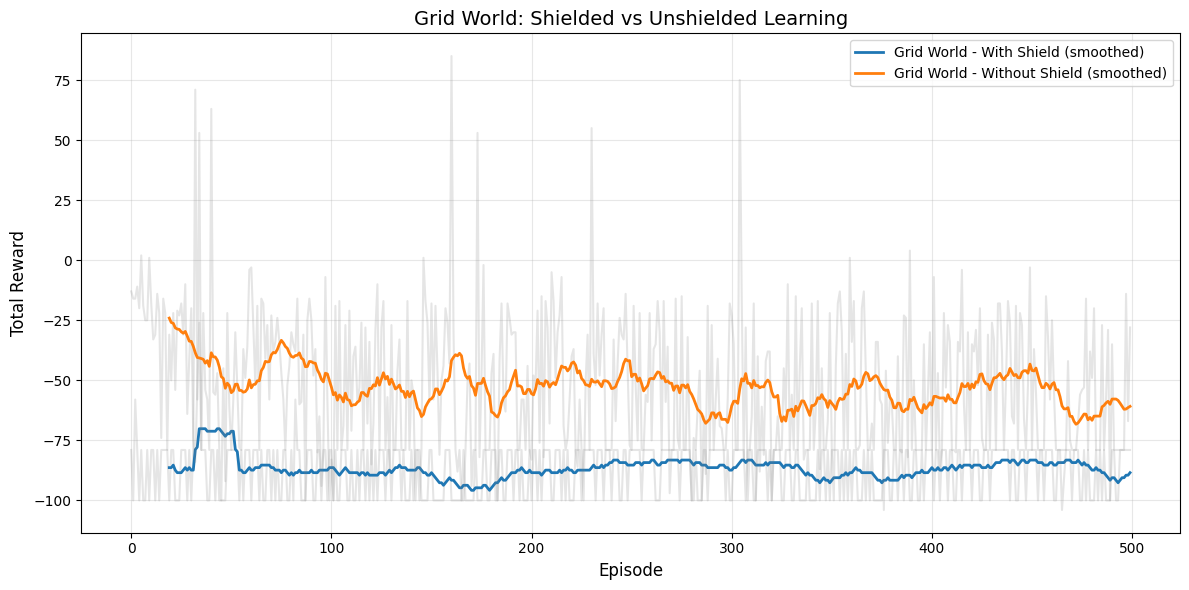

✅ Graph saved as 'water_tank_results.png'


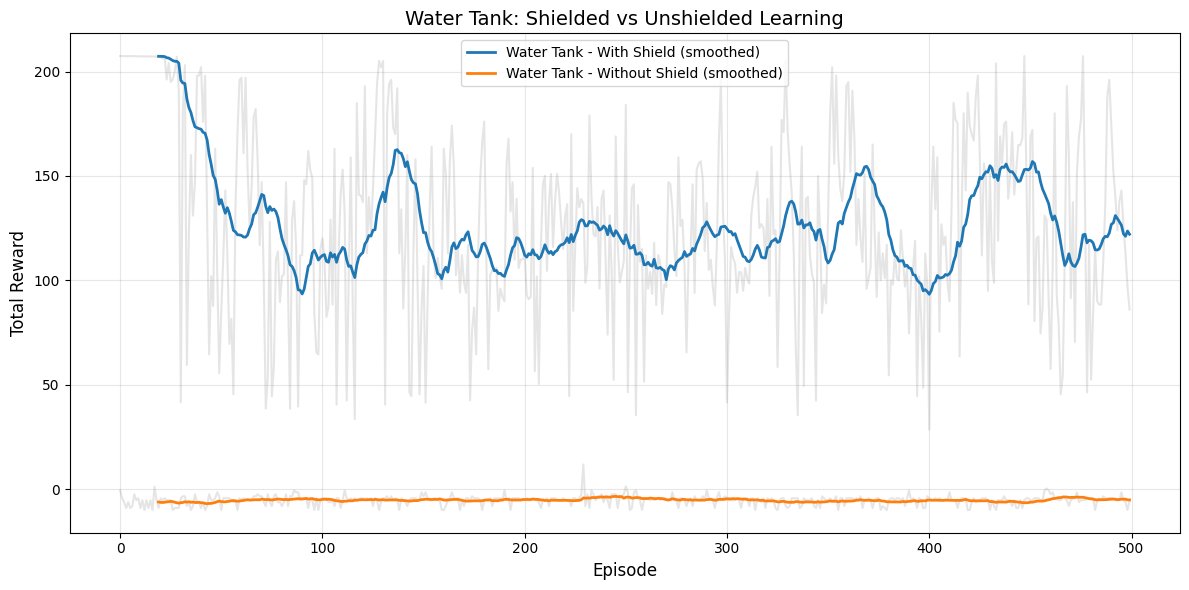


📊 FINAL SUMMARY

────────────────────────────────────────
GRID WORLD RESULTS
────────────────────────────────────────
  With Shield - Success: 0/100, Corrections: 0
  Without Shield - Success: 0/100, Corrections: 0
  Avg With Shield (last 20): -88.45
  Avg Without Shield (last 20): -60.85

────────────────────────────────────────
WATER TANK RESULTS
────────────────────────────────────────
  With Shield - Success: 500/100, Corrections: 1047
  Without Shield - Success: 4/100, Corrections: 0
  Avg With Shield (last 20): 122.09
  Avg Without Shield (last 20): -5.16

🎉 ALL DONE!
📊 Two graphs will appear above.
💡 The shield blocks unsafe actions during learning.


In [5]:
# ============================================
# SHIELDED REINFORCEMENT LEARNING
# ============================================

import random
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("SHIELDED REINFORCEMENT LEARNING")
print("="*60)

# ============================================
# SHIELD CLASS
# ============================================

class Shield:
    def __init__(self, env_type='grid'):
        self.env_type = env_type
        self.corrections = 0

    def get_safe_action(self, observation, action_ranking):
        for action in action_ranking:
            if self._is_safe(observation, action):
                return action, True

        all_actions = [0, 1, 2, 3]
        for action in all_actions:
            if self._is_safe(observation, action):
                self.corrections += 1
                return action, False

        return action_ranking[0], False

    def _is_safe(self, obs, action):
        if self.env_type == 'grid':
            pos = obs.get('position', (4, 4))
            walls = obs.get('walls', [])
            size = obs.get('size', 9)

            x, y = pos
            if action == 0: nx, ny = x, y-1
            elif action == 1: nx, ny = x, y+1
            elif action == 2: nx, ny = x-1, y
            elif action == 3: nx, ny = x+1, y
            else: return False

            if nx < 0 or nx >= size or ny < 0 or ny >= size: return False
            if (nx, ny) in walls: return False
            return True

        elif self.env_type == 'water':
            level = obs.get('level', 50)
            valve_open = obs.get('valve_open', False)
            open_dur = obs.get('open_duration', 0)
            close_dur = obs.get('close_duration', 0)

            if action == 1 and level > 90: return False
            if action == 0 and level < 10: return False
            if not valve_open and action == 1 and close_dur < 3: return False
            if valve_open and action == 0 and open_dur < 3: return False
            return True

        return True


# ============================================
# Q-LEARNING AGENT
# ============================================

class QLearningAgent:
    def __init__(self, num_states, num_actions):
        self.num_states = num_states
        self.num_actions = num_actions
        self.q_table = []
        for i in range(num_states):
            self.q_table.append([0.0] * num_actions)
        self.lr = 0.1
        self.gamma = 0.9
        self.epsilon = 0.1

    def state_to_index(self, state):
        if isinstance(state, tuple):
            x, y = state
            idx = x * 9 + y
            if idx >= self.num_states:
                return self.num_states - 1
            if idx < 0:
                return 0
            return idx

        if isinstance(state, (int, float)):
            idx = int(state)
            if idx >= self.num_states:
                return self.num_states - 1
            if idx < 0:
                return 0
            return idx

        return 0

    def get_action_ranking(self, state):
        idx = self.state_to_index(state)

        if random.random() < self.epsilon:
            action = random.randint(0, self.num_actions - 1)
            ranking = [action]
            others = [a for a in range(self.num_actions) if a != action]
            others.sort(key=lambda a: self.q_table[idx][a], reverse=True)
            ranking.extend(others)
            return ranking

        ranking = list(range(self.num_actions))
        ranking.sort(key=lambda a: self.q_table[idx][a], reverse=True)
        return ranking

    def get_max_q(self, state_idx):
        if state_idx >= len(self.q_table):
            state_idx = len(self.q_table) - 1
        if state_idx < 0:
            state_idx = 0

        max_val = self.q_table[state_idx][0]
        for val in self.q_table[state_idx]:
            if val > max_val:
                max_val = val
        return max_val

    def update(self, state, action, reward, next_state, done):
        idx = self.state_to_index(state)
        next_idx = self.state_to_index(next_state)

        if idx >= len(self.q_table):
            idx = len(self.q_table) - 1
        if idx < 0:
            idx = 0
        if next_idx >= len(self.q_table):
            next_idx = len(self.q_table) - 1
        if next_idx < 0:
            next_idx = 0

        if action >= len(self.q_table[idx]):
            action = len(self.q_table[idx]) - 1
        if action < 0:
            action = 0

        best_next = self.get_max_q(next_idx)
        target = reward + self.gamma * best_next * (not done)
        self.q_table[idx][action] += self.lr * (target - self.q_table[idx][action])


# ============================================
# GRID WORLD ENVIRONMENT
# ============================================

class GridWorld:
    def __init__(self):
        self.size = 9
        self.walls = []
        for i in range(self.size):
            self.walls.append((0, i))
            self.walls.append((self.size-1, i))
            self.walls.append((i, 0))
            self.walls.append((i, self.size-1))

        self.goals = [(2, 2), (6, 6), (2, 6)]
        self.current_goal = 0
        self.start = (4, 4)
        self.pos = self.start
        self.done = False
        self.steps = 0
        self.max_steps = 100

    def reset(self):
        self.pos = self.start
        self.current_goal = 0
        self.done = False
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        return {'position': self.pos, 'walls': self.walls, 'size': self.size}

    def step(self, action):
        self.steps += 1
        x, y = self.pos

        if action == 0: nx, ny = x, y-1
        elif action == 1: nx, ny = x, y+1
        elif action == 2: nx, ny = x-1, y
        elif action == 3: nx, ny = x+1, y
        else: return self._get_obs(), -1, True, {}

        if (nx, ny) in self.walls:
            return self._get_obs(), -10, True, {'crash': True}

        self.pos = (nx, ny)
        reward = -1

        if self.current_goal < len(self.goals):
            if self.pos == self.goals[self.current_goal]:
                self.current_goal += 1
                reward = 20

        if self.current_goal >= len(self.goals):
            reward = 100
            self.done = True

        if self.steps >= self.max_steps:
            self.done = True

        return self._get_obs(), reward, self.done, {}

    def render(self):
        grid = [['.' for _ in range(self.size)] for _ in range(self.size)]
        for x, y in self.walls:
            if 0 <= x < self.size and 0 <= y < self.size:
                grid[y][x] = '#'
        for i, (gx, gy) in enumerate(self.goals):
            if i >= self.current_goal:
                grid[gy][gx] = str(i+1)
        px, py = self.pos
        grid[py][px] = 'A'
        for row in grid:
            print(' '.join(row))
        print()


# ============================================
# WATER TANK ENVIRONMENT
# ============================================

class WaterTank:
    def __init__(self):
        self.level = 50.0
        self.valve_open = False
        self.open_duration = 0
        self.close_duration = 0
        self.done = False
        self.steps = 0
        self.max_steps = 200

    def reset(self):
        self.level = 50.0
        self.valve_open = False
        self.open_duration = 0
        self.close_duration = 0
        self.done = False
        self.steps = 0
        return self._get_obs()

    def _get_obs(self):
        return {
            'level': self.level,
            'valve_open': self.valve_open,
            'open_duration': self.open_duration,
            'close_duration': self.close_duration
        }

    def step(self, action):
        self.steps += 1
        reward = 0

        if action == 1 and not self.valve_open:
            if self.close_duration >= 3:
                self.valve_open = True
                self.open_duration = 0
                self.close_duration = 0
            else:
                self.done = True
                return self._get_obs(), -10, True, {}

        elif action == 0 and self.valve_open:
            if self.open_duration >= 3:
                self.valve_open = False
                self.close_duration = 0
                self.open_duration = 0
            else:
                self.done = True
                return self._get_obs(), -10, True, {}

        if self.valve_open:
            self.level += 1.5 + random.uniform(-0.3, 0.3)
            self.open_duration += 1
            self.close_duration = 0
            reward -= 0.1
        else:
            self.level -= 0.5 + random.uniform(-0.1, 0.1)
            self.close_duration += 1
            self.open_duration = 0
            reward -= 0.05

        if self.level > 100:
            self.done = True
            return self._get_obs(), -50, True, {}

        if self.level < 0:
            self.done = True
            return self._get_obs(), -50, True, {}

        if 30 < self.level < 70:
            reward += 1

        if self.steps >= self.max_steps:
            self.done = True
            reward += 20

        return self._get_obs(), reward, self.done, {}


# ============================================
# TRAINING FUNCTIONS
# ============================================

def calculate_average(list_values):
    if not list_values:
        return 0
    return sum(list_values) / len(list_values)

def moving_average(data, window=20):
    """Calculate moving average without numpy"""
    if len(data) < window:
        return data
    result = []
    for i in range(len(data) - window + 1):
        avg = sum(data[i:i+window]) / window
        result.append(avg)
    return result

def train_gridworld(use_shield=True, episodes=100):
    print("\n" + "="*60)
    print("TRAINING GRID WORLD")
    print("="*60)

    env = GridWorld()
    shield = Shield(env_type='grid')
    agent = QLearningAgent(num_states=81, num_actions=4)

    rewards = []
    successes = 0
    shield_corrections = 0

    for episode in range(episodes):
        obs = env.reset()
        state = obs['position']
        total_reward = 0
        done = False
        episode_corrections = 0

        while not done:
            ranking = agent.get_action_ranking(state)

            if use_shield:
                action, was_agent = shield.get_safe_action(obs, ranking)
                if not was_agent:
                    episode_corrections += 1
            else:
                action = ranking[0]

            next_obs, reward, done, info = env.step(action)
            next_state = next_obs['position']

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            state = next_state
            obs = next_obs

        shield_corrections += episode_corrections
        rewards.append(total_reward)

        if total_reward >= 100:
            successes += 1

        if (episode + 1) % 25 == 0 or episode == 0:
            print(f"Episode {episode}: Reward = {total_reward:.1f}, Corrections = {episode_corrections}")

    print(f"\nSuccess rate: {successes}/{episodes} = {successes/episodes*100:.1f}%")
    print(f"Total shield corrections: {shield_corrections}")
    return rewards, successes, shield_corrections


def train_watertank(use_shield=True, episodes=100):
    print("\n" + "="*60)
    print("TRAINING WATER TANK")
    print("="*60)

    env = WaterTank()
    shield = Shield(env_type='water')
    agent = QLearningAgent(num_states=201, num_actions=2)

    rewards = []
    successes = 0
    shield_corrections = 0

    for episode in range(episodes):
        obs = env.reset()
        state = int(obs['level'])
        total_reward = 0
        done = False
        episode_corrections = 0

        while not done:
            ranking = agent.get_action_ranking(state)

            if use_shield:
                action, was_agent = shield.get_safe_action(obs, ranking)
                if not was_agent:
                    episode_corrections += 1
            else:
                action = ranking[0]

            next_obs, reward, done, info = env.step(action)
            next_state = int(next_obs['level'])

            agent.update(state, action, reward, next_state, done)

            total_reward += reward
            state = next_state
            obs = next_obs

        shield_corrections += episode_corrections
        rewards.append(total_reward)

        if total_reward > 0:
            successes += 1

        if (episode + 1) % 25 == 0 or episode == 0:
            print(f"Episode {episode}: Reward = {total_reward:.1f}, Corrections = {episode_corrections}")

    print(f"\nSuccess rate: {successes}/{episodes} = {successes/episodes*100:.1f}%")
    print(f"Total shield corrections: {shield_corrections}")
    return rewards, successes, shield_corrections


# ============================================
# PLOTTING FUNCTIONS
# ============================================

def plot_learning_curves(data_dict, title, filename):
    """Plot learning curves with moving average"""
    plt.figure(figsize=(12, 6))

    for label, rewards in data_dict.items():
        # Raw data (transparent)
        plt.plot(rewards, alpha=0.2, color='gray')

        # Moving average
        window = min(20, len(rewards))
        if len(rewards) >= window:
            ma = moving_average(rewards, window)
            plt.plot(range(window-1, len(rewards)), ma,
                    label=f'{label} (smoothed)', linewidth=2)

    plt.xlabel('Episode', fontsize=12)
    plt.ylabel('Total Reward', fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    # Save in Colab
    try:
        plt.savefig(f'{filename}.png')
        print(f"✅ Graph saved as '{filename}.png'")
    except:
        print("⚠️ Could not save file, but showing graph")

    plt.show()


# ============================================
# MAIN - RUN EVERYTHING
# ============================================

print("\n" + "="*60)
print("SHIELDED REINFORCEMENT LEARNING")
print("GOOGLE COLAB VERSION")
print("="*60)
print("\nThis will run two experiments:")
print("1. Grid World (9x9) - 100 episodes each")
print("2. Water Tank - 100 episodes each")
print("\nEach experiment runs with and without the shield.")
print("="*60)

# ============================================
# EXPERIMENT 1: GRID WORLD
# ============================================

print("\n🚀 Starting Grid World Experiment...")

print("\n" + "─"*40)
print("Training WITH Shield:")
print("─"*40)
grid_shielded, g_succ_w, g_corr_w = train_gridworld(use_shield=True, episodes=500)

print("\n" + "─"*40)
print("Training WITHOUT Shield:")
print("─"*40)
grid_unshielded, g_succ_wo, g_corr_wo = train_gridworld(use_shield=False, episodes=500)

# ============================================
# EXPERIMENT 2: WATER TANK
# ============================================

print("\n🚀 Starting Water Tank Experiment...")

print("\n" + "─"*40)
print("Training WITH Shield:")
print("─"*40)
water_shielded, w_succ_w, w_corr_w = train_watertank(use_shield=True, episodes=500)

print("\n" + "─"*40)
print("Training WITHOUT Shield:")
print("─"*40)
water_unshielded, w_succ_wo, w_corr_wo = train_watertank(use_shield=False, episodes=500)

# ============================================
# PLOT RESULTS
# ============================================

print("\n" + "="*60)
print("📊 GENERATING GRAPHS...")
print("="*60)

# Graph 1: Grid World
plot_learning_curves({
    'Grid World - With Shield': grid_shielded,
    'Grid World - Without Shield': grid_unshielded
}, 'Grid World: Shielded vs Unshielded Learning', 'grid_world_results')

# Graph 2: Water Tank
plot_learning_curves({
    'Water Tank - With Shield': water_shielded,
    'Water Tank - Without Shield': water_unshielded
}, 'Water Tank: Shielded vs Unshielded Learning', 'water_tank_results')

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*60)
print("📊 FINAL SUMMARY")
print("="*60)

print("\n" + "─"*40)
print("GRID WORLD RESULTS")
print("─"*40)
print(f"  With Shield - Success: {g_succ_w}/100, Corrections: {g_corr_w}")
print(f"  Without Shield - Success: {g_succ_wo}/100, Corrections: {g_corr_wo}")
print(f"  Avg With Shield (last 20): {calculate_average(grid_shielded[-20:]):.2f}")
print(f"  Avg Without Shield (last 20): {calculate_average(grid_unshielded[-20:]):.2f}")

print("\n" + "─"*40)
print("WATER TANK RESULTS")
print("─"*40)
print(f"  With Shield - Success: {w_succ_w}/100, Corrections: {w_corr_w}")
print(f"  Without Shield - Success: {w_succ_wo}/100, Corrections: {w_corr_wo}")
print(f"  Avg With Shield (last 20): {calculate_average(water_shielded[-20:]):.2f}")
print(f"  Avg Without Shield (last 20): {calculate_average(water_unshielded[-20:]):.2f}")

print("\n" + "="*60)
print("🎉 ALL DONE!")
print("📊 Two graphs will appear above.")
print("💡 The shield blocks unsafe actions during learning.")
print("="*60)